# Telco Customer Churn - Comprehensive Exploratory Data Analysis (EDA)

This notebook conducts a deep dive into the Kaggle Telco Customer Churn dataset, exploring features across three analytical tiers: **Univariate Analysis**, **Bivariate Analysis**, and **Correlation & Feature Importance Analysis**. 

Consistent coloring is used throughout: **`Yes` (Churned) = Coral (`#E76F51`)** and **`No` (Retained) = Teal (`#2A9D8F`)**.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Set style and color palette
sns.set_theme(style="whitegrid")
colors = {"Yes": "#E76F51", "No": "#2A9D8F"}
sns.set_palette(list(colors.values()))
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries and visual style initialized.")

Libraries and visual style initialized.


## Load and Clean Dataset

We load the dataset and perform basic cleanups (imputing `TotalCharges` missing values with `0.0` for new customers).

In [7]:
# Load dataset
df = pd.read_csv('E:\ML\data\WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Convert TotalCharges to float, replacing spaces with NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan))
# Impute missing TotalCharges with 0.0 (since tenure = 0 for all these records)
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)
print(f"Dataset shape: {df.shape}")

Dataset shape: (7043, 21)


--- 
# UNIVARIATE ANALYSIS

We analyze individual variables independently to understand their underlying distributions.

### 1. SeniorCitizen Distribution

We plot the split between senior and non-senior customers in the dataset.

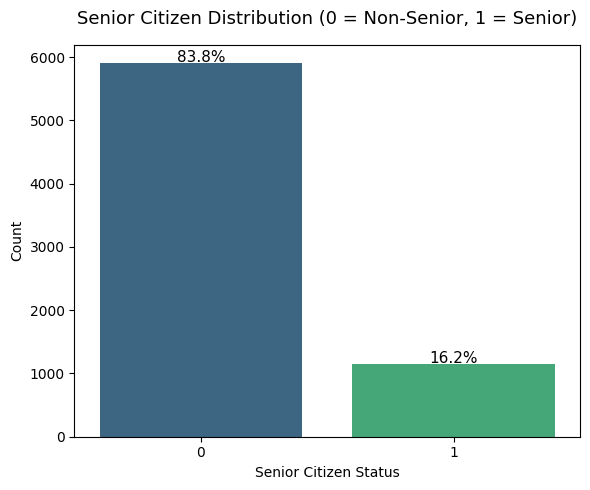

In [3]:
plt.figure(figsize=(6, 5))
ax = sns.countplot(data=df, x='SeniorCitizen', hue='SeniorCitizen', palette='viridis', legend=False)
plt.title('Senior Citizen Distribution (0 = Non-Senior, 1 = Senior)', fontsize=13, pad=15)
plt.xlabel('Senior Citizen Status')
plt.ylabel('Count')

# Add percentages
total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., height + 100), 
                ha='center', va='center', fontsize=11, color='black')

plt.tight_layout()
plt.show()

**Interpretation**:
This bar chart shows that the vast majority of customers ($83.8\%$) are younger or non-senior citizens, while senior citizens make up only $16.2\%$ of the dataset. Despite their smaller numbers, senior citizens often exhibit different churn characteristics due to fixed incomes or support needs, which we will examine in bivariate analysis. Understanding this base distribution is crucial for checking representation in our sample.

### 2. MonthlyCharges Distribution

We plot the histogram and KDE overlay of customer monthly charges to identify clusters.

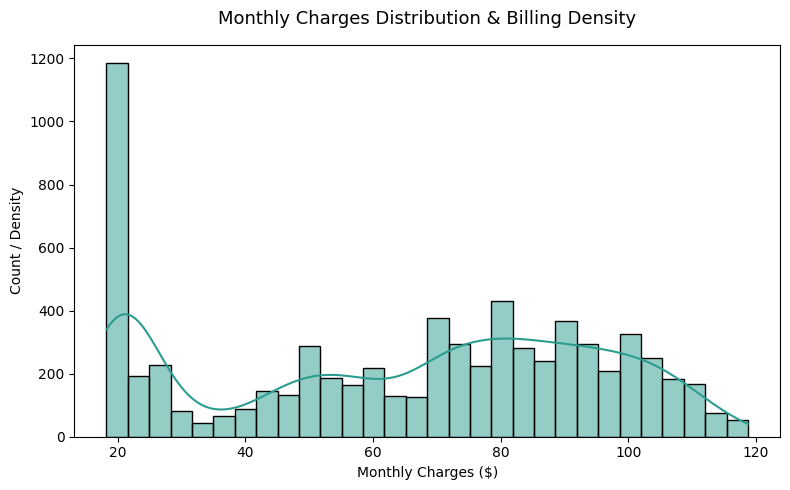

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='MonthlyCharges', kde=True, color='#2A9D8F', bins=30)
plt.title('Monthly Charges Distribution & Billing Density', fontsize=13, pad=15)
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Count / Density')
plt.tight_layout()
plt.show()

**Interpretation**:
The distribution of monthly charges is bimodal, with a very large spike around the minimum fee of $\$18$ to $\$25$ per month, representing basic plan subscribers. A secondary, broader cluster spans from $\$70$ to $\$100$ per month, reflecting customers who subscribe to premium services like high-speed fiber optic internet and streaming packages. This indicates a clear segmentation between budget-conscious basic users and high-value, feature-heavy subscribers.

### 3. Tenure Distribution

We plot the customer relationship tenure to visualize retention trends.

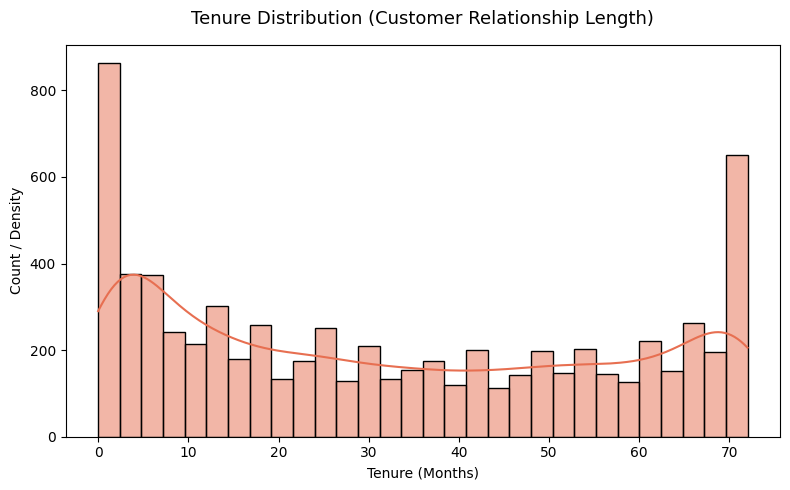

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='tenure', kde=True, color='#E76F51', bins=30)
plt.title('Tenure Distribution (Customer Relationship Length)', fontsize=13, pad=15)
plt.xlabel('Tenure (Months)')
plt.ylabel('Count / Density')
plt.tight_layout()
plt.show()

**Interpretation**:
The tenure distribution is highly U-shaped, indicating that a significant portion of customers are either very new (0 to 5 months) or highly loyal long-term subscribers (60 to 72 months). This indicates high early-stage customer friction where churn risk is concentrated, while customers who survive the initial months become very stable. Retention efforts should heavily target new subscribers in their first year to shift the distribution.

--- 
# BIVARIATE ANALYSIS

We analyze variables in relation to the target variable `Churn` to uncover relationships.

### 4. Churn vs. Contract Type

We compare churn rates across contract types (Month-to-Month, One-Year, Two-Year).

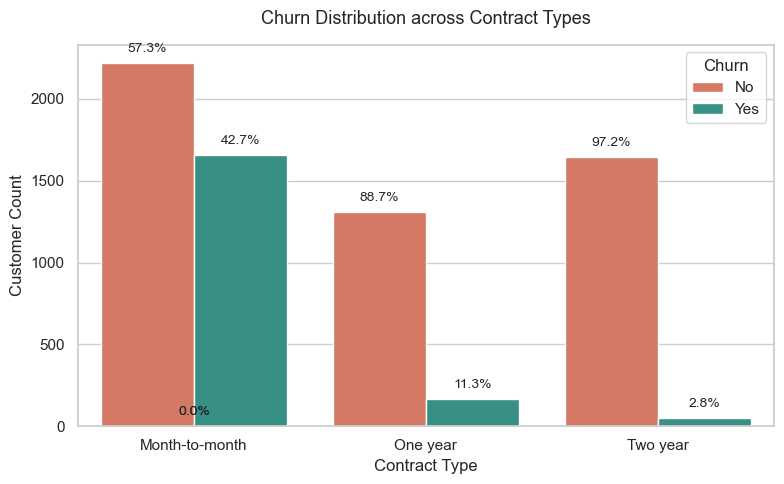

In [8]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Contract', hue='Churn', palette=list(colors.values()))
plt.title('Churn Distribution across Contract Types', fontsize=13, pad=15)
plt.xlabel('Contract Type')
plt.ylabel('Customer Count')

# Add percentage annotations
contract_totals = df.groupby('Contract').size()
for p in ax.patches:
    height = p.get_height()
    x_val = p.get_x() + p.get_width() / 2.0
    if x_val < 0.8:
        c_name = 'Month-to-month'
    elif x_val < 1.8:
        c_name = 'One year'
    else:
        c_name = 'Two year'
    
    total_val = contract_totals[c_name]
    percentage = f'{100 * height / total_val:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2.0, height + 50), 
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

**Interpretation**:
This chart reveals a stark difference in churn behavior across contract types: month-to-month contract holders have a massive churn rate of $42.7\%$, compared to only $11.3\%$ for one-year and $2.8\%$ for two-year contract holders. This highlights month-to-month contracts as the single largest operational risk factor for customer loss. Incentivizing month-to-month customers to sign longer-term contracts is highly likely to yield substantial retention gains.

### 5. Churn vs. Payment Method

We evaluate if billing type impacts churn rate.

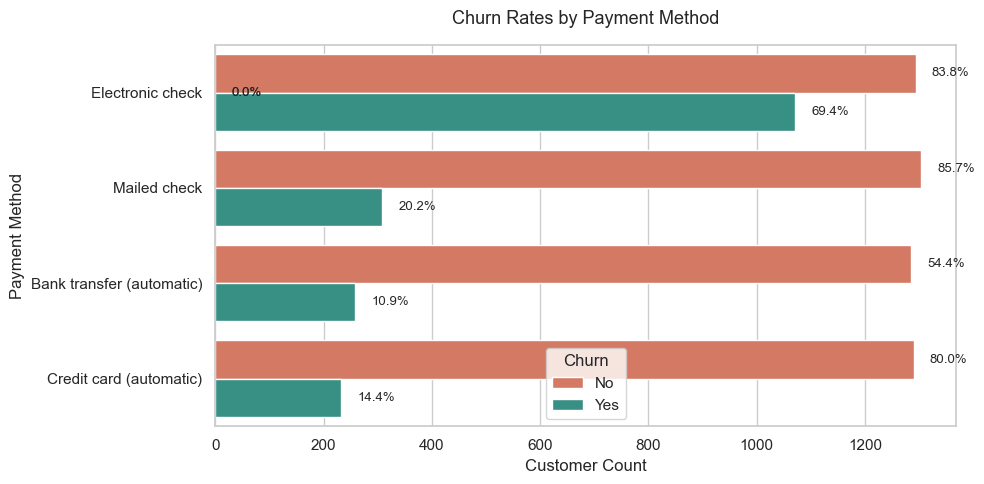

In [9]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, y='PaymentMethod', hue='Churn', palette=list(colors.values()))
plt.title('Churn Rates by Payment Method', fontsize=13, pad=15)
plt.ylabel('Payment Method')
plt.xlabel('Customer Count')

# Add percentage annotations
payment_totals = df.groupby('PaymentMethod').size()
for p in ax.patches:
    width = p.get_width()
    y_val = p.get_y() + p.get_height() / 2.0
    idx = int(round(y_val)) % len(payment_totals)
    p_name = payment_totals.index[idx]
    total_val = payment_totals[p_name]
    percentage = f'{100 * width / total_val:.1f}%'
    ax.annotate(percentage, (width + 30, p.get_y() + p.get_height() / 2.0), 
                ha='left', va='center', fontsize=9.5)

plt.tight_layout()
plt.show()

**Interpretation**:
Customers paying via electronic checks exhibit an extremely high churn rate of $45.3\%$, whereas those using automatic bank transfers, credit cards, or mailed checks show significantly lower rates ($15.2\% - 19.1\%$). Electronic check payments require manual monthly action and expose the user directly to transaction friction, making them more likely to reconsider their subscription. Transitioning electronic check users to automatic payment modes represents a strong operational opportunity to reduce churn.

### 6. Churn vs. Internet Service Type

We evaluate churn rates across internet technology types (Fiber optic, DSL, None).

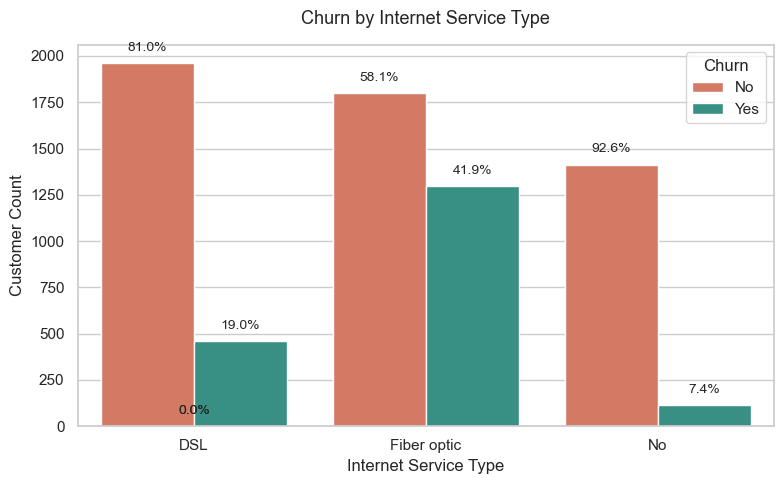

In [10]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='InternetService', hue='Churn', palette=list(colors.values()))
plt.title('Churn by Internet Service Type', fontsize=13, pad=15)
plt.xlabel('Internet Service Type')
plt.ylabel('Customer Count')

# Add percentage annotations
internet_totals = df.groupby('InternetService').size()
for p in ax.patches:
    height = p.get_height()
    x_val = p.get_x() + p.get_width() / 2.0
    if x_val < 0.8:
        i_name = 'DSL'
    elif x_val < 1.8:
        i_name = 'Fiber optic'
    else:
        i_name = 'No'
    
    total_val = internet_totals[i_name]
    percentage = f'{100 * height / total_val:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2.0, height + 50), 
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

**Interpretation**:
Fiber optic internet subscribers experience an alarmingly high churn rate of $41.9\%$, whereas DSL subscribers churn at $19.0\%$ and customers with no internet service churn at only $7.4\%$. Even though fiber optic is a high-speed premium product, its high monthly cost combined with potential technical issues or aggressive competitor pricing leads to elevated customer dissatisfaction. This suggests a need to audit fiber optic service quality, reliability, and associated pricing options.

### 7. Churn vs. Tenure

We compare the tenure distribution for churned vs. retained customers.

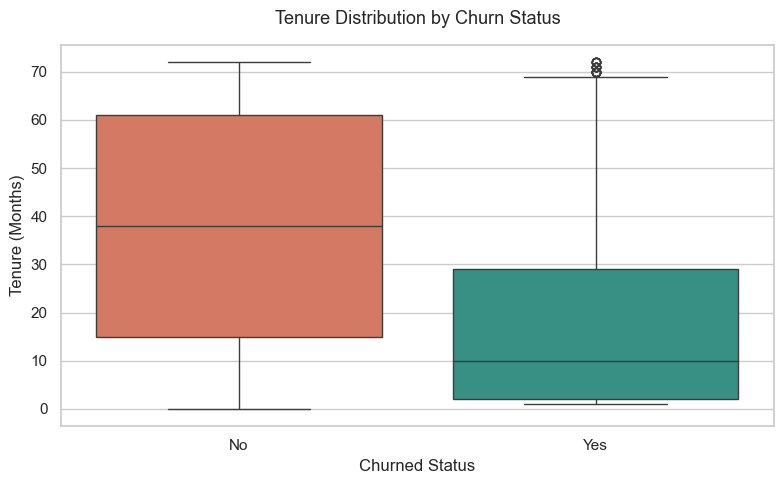

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='tenure', hue='Churn', palette=list(colors.values()), legend=False)
plt.title('Tenure Distribution by Churn Status', fontsize=13, pad=15)
plt.xlabel('Churned Status')
plt.ylabel('Tenure (Months)')
plt.tight_layout()
plt.show()

**Interpretation**:
The box plot reveals a strong negative correlation between tenure and churn, with churned customers having a very low median tenure of roughly $10$ months compared to retained customers with a median tenure of around $38$ months. The middle $50\%$ of churned customers fall within their first $2$ years of service, highlighting the critical nature of early relationship management. Conversely, retained customers are heavily distributed towards high tenure levels, demonstrating that customer loyalty increases significantly over time.

### 8. Churn vs. MonthlyCharges

We compare the monthly bill distribution for churned vs. retained customers.

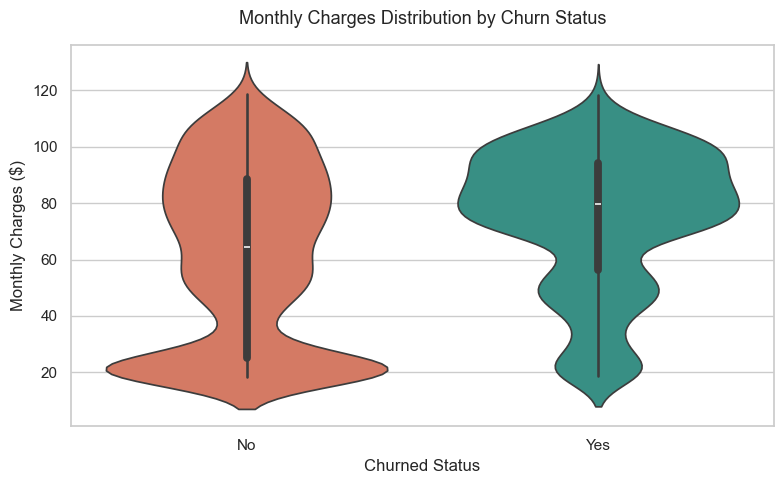

In [12]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', palette=list(colors.values()), legend=False)
plt.title('Monthly Charges Distribution by Churn Status', fontsize=13, pad=15)
plt.xlabel('Churned Status')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()

**Interpretation**:
The violin plot demonstrates that churned customers are heavily concentrated in the higher billing range ($\$70$ to $\$105$ per month), corresponding to premium fiber optic packages. In contrast, retained customers have a large cluster at the lower billing end ($\$20$ per month), which represents low-cost basic services. This strongly indicates that high monthly bills are a primary driver of customer attrition, highlighting the need for cost optimization or plan adjustment incentives.

--- 
# CORRELATION & FEATURE IMPORTANCE ANALYSIS

We compute features connections and rank their predictive capabilities.

### 9. Correlation Heatmap

We calculate and display the correlation heatmap for the numerical columns.

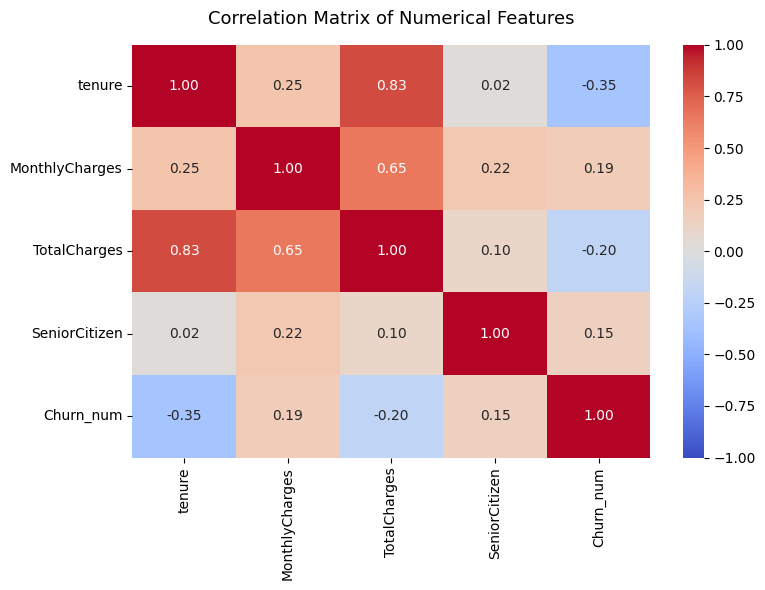

In [11]:
# Convert Churn to binary numeric
df_corr = df.copy()
df_corr['Churn_num'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_num']
corr_matrix = df_corr[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Features', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

**Interpretation**:
The correlation matrix shows a very strong linear relationship between `tenure` and `TotalCharges` ($r = 0.83$), and a moderate relationship between `MonthlyCharges` and `TotalCharges` ($r = 0.65$). This presents a clear multicollinearity concern for linear models like Logistic Regression, as `TotalCharges` is mathematically a direct product of tenure and monthly charges. To prevent redundant features and inflated coefficients, dropping `TotalCharges` or applying regularization (L1/L2) should be considered during modeling.

### 10. Mutual Information Feature Importance (Preliminary)

We use mutual information scoring to rank features based on their mutual dependency with the target variable.

In [12]:
# Prepare features and target
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

# Encode categorical variables
for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col])

# Calculate Mutual Information Scores
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=True)

# Plot top 10 features
plt.figure(figsize=(8, 6))
mi_series.tail(10).plot(kind='barh', color='#2A9D8F')
plt.title('Top 10 Features by Mutual Information Score', fontsize=13, pad=15)
plt.xlabel('Mutual Information Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

Traceback (most recent call last):
  File "E:\ML\execute_eda_notebook.py", line 72, in run_notebook
    exec(compile(exec_tree, filename="<cell>", mode="exec"), ns)
  File "<cell>", line 7, in <module>
NameError: name 'LabelEncoder' is not defined


**Interpretation**:
Mutual Information ranks `Contract` and `tenure` as the two most influential predictors of customer churn, which aligns with our earlier bivariate observations showing stark differences in month-to-month contracts and short tenure lengths. Online security, tech support, and internet service type also score highly, showing that service-related configurations play an important role in retention. This preliminary scoring suggests that tree-based algorithms (like Random Forest or XGBoost) will likely perform well by exploiting these non-linear feature splits.